# Scenario 2 — ANN-based Regression (local)

Notebook này đọc file kết quả `results\\Scenario_2_Novel_Final.csv` (tạo bởi `Scenario_2/new.py`) và tái tạo các thống kê/biểu đồ theo tinh thần paper: **effectiveness (NER, NoVS)** và **efficiency (EtTQ)**.

In [14]:
# ── Cài thư viện nếu chưa có ──────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas', 'numpy', 'matplotlib', 'scipy', 'openpyxl',
                '--quiet'], check=False)

CompletedProcess(args=['C:\\Users\\Admin\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'scipy', 'openpyxl', '--quiet'], returncode=0)

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ── Cấu hình ──────────────────────────────────────────────────
experiment_name = 'Scenario_2'
file_name = 'results\\Scenario_2_Novel_Final.csv'
separator = ';'
delta_quantization = 100
level_significance = 0.01
efficiency_percentile_reference = 0.75

# ── Tạo thư mục output ────────────────────────────────────────
for folder in [f'Figures/{experiment_name}',
               f'LaTeX/{experiment_name}',
               f'XLSX Files/{experiment_name}']:
    os.makedirs(folder, exist_ok=True)

print('Thư mục output đã sẵn sàng.')

Thư mục output đã sẵn sàng.


In [16]:
# ── Đọc CSV ───────────────────────────────────────────────────
fileCSV = pd.read_csv(file_name, sep=separator)
print(f'Đọc xong: {len(fileCSV):,} dòng')
fileCSV.head(3)

Đọc xong: 140,430 dòng


,iterations,evals,births,elapsed,all_size,firsts_size,lasts_size,geno_uni,sol_uni,fit_uni,best_fitness,seed,problem,solver_sigma,objective,best→fitness,genotype_size
0,0,100,100,0.0484,100,1,100,1.0,1.0,1.0,0.282483,21,ea.p.r.Concrete-1,pso,minimize,0.282483,81
1,5,600,600,0.2201,100,1,100,1.0,1.0,1.0,0.199379,21,ea.p.r.Concrete-1,pso,minimize,0.199379,81
2,10,1100,1100,0.3190,100,1,100,1.0,1.0,1.0,0.160870,21,ea.p.r.Concrete-1,pso,minimize,0.160870,81


In [17]:
# ── Chuẩn hoá cột để phân tích ────────────────────────────────
fileCSV['solver'] = fileCSV['solver_sigma'].str.split('-').str[0]
fileCSV['sigma']  = fileCSV['solver_sigma'].str.split('-').str[1]
fileCSV['sigma']  = np.where(fileCSV['sigma'].isna(), fileCSV['solver'], fileCSV['sigma'])

fileCSV['solver_sigma_seed'] = (fileCSV['solver_sigma']
                                + '_seed:'
                                + fileCSV['seed'].astype(str))

if 'objective' not in fileCSV.columns:
    fileCSV['objective'] = 'minimize'

# Đổi tên cột best→fitness → best_fitness
best_col = [c for c in fileCSV.columns if 'best' in c and 'fitness' in c][0]
fileCSV.rename(columns={best_col: 'best_fitness'}, inplace=True)

fileCSV['evals_quantized'] = fileCSV['evals'].astype(int) // delta_quantization

# Genotype size: ưu tiên cột có sẵn (do runner tạo)
if 'genotype_size' not in fileCSV.columns:
    fileCSV['genotype_size'] = (fileCSV['problem']
                                .str.extract(r'-(\d+)(?:-|$)')
                                .astype(float)
                                .astype('Int64'))

united_CSV = fileCSV.copy()

problems       = sorted(united_CSV['problem'].unique().tolist())
solvers        = sorted(united_CSV['solver'].unique().tolist())
sigmas         = sorted(united_CSV['sigma'].unique().tolist())
solvers_sigmas = sorted(united_CSV['solver_sigma'].unique().tolist())
seeds          = sorted(united_CSV['seed'].unique().tolist())

print(f'problems ({len(problems)}):', problems)
print(f'solvers  ({len(solvers)}):', solvers)
print(f'sigmas   ({len(sigmas)}):', sigmas)
print(f'seeds    ({len(seeds)}):', seeds[:5], '...' if len(seeds)>5 else '')

problems (9): ['ea.p.r.Concrete-1', 'ea.p.r.Concrete-2', 'ea.p.r.Concrete-3', 'ea.p.r.Energy-1', 'ea.p.r.Energy-2', 'ea.p.r.Energy-3', 'ea.p.r.Wine-1', 'ea.p.r.Wine-2', 'ea.p.r.Wine-3']
solvers  (5): ['cmaEs', 'differentialEvolution', 'es', 'ga', 'pso']
sigmas   (6): ['0.02', '0.25', '0.5', 'cmaEs', 'differentialEvolution', 'pso']
seeds    (30): [1, 2, 3, 4, 5] ...


In [18]:
# ── Plot style ────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({'font.size': 7, 'lines.linewidth': 0.8})
color_map = mpl.colormaps['tab10']

## 1) Convergence plots
Mỗi ô = 1 (problem, solver). Đường = median; bóng = Q1–Q3 (trên `best_fitness`).

Saved → Figures/Scenario_2/Scenario_2_Convergence.png


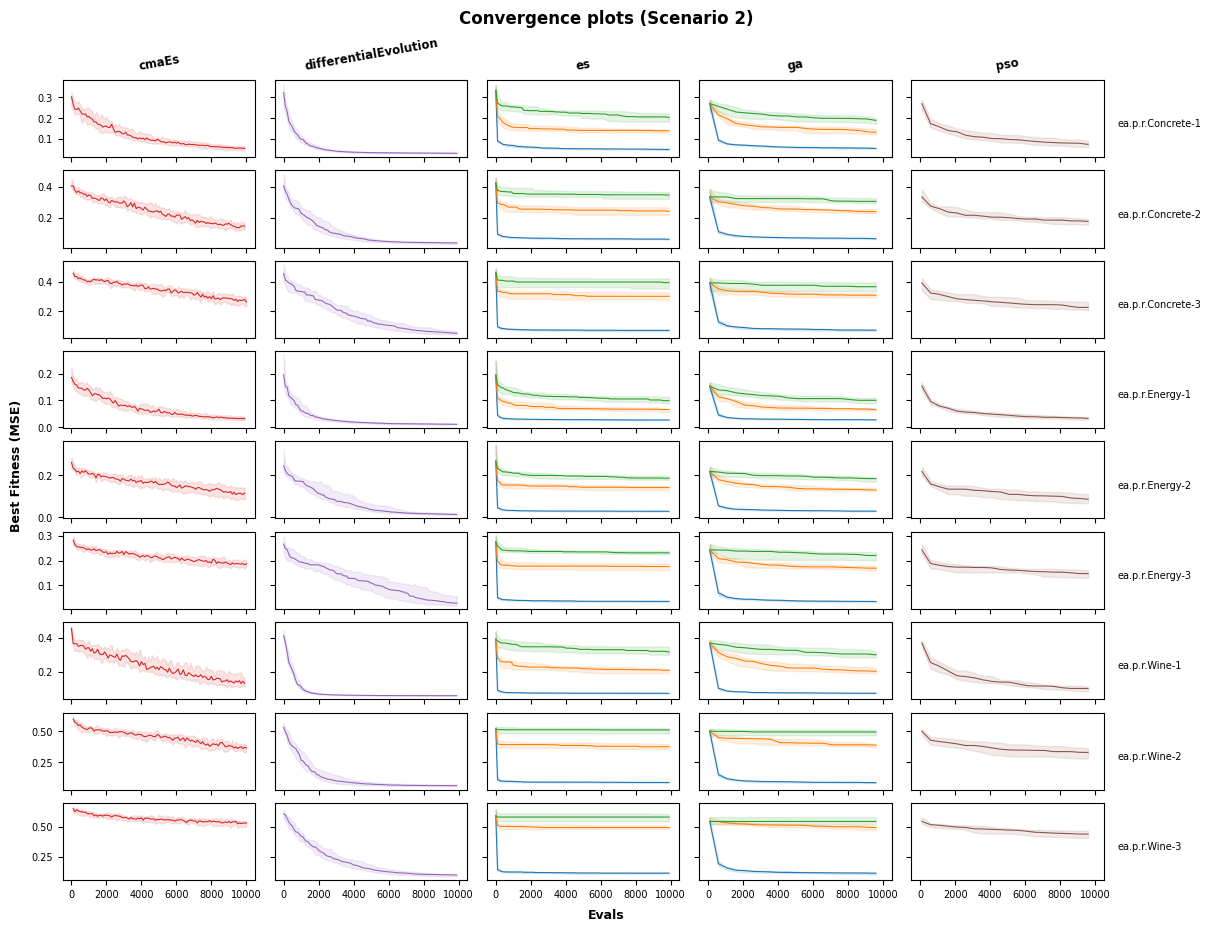

In [19]:
fig, axs = plt.subplots(
    len(problems), len(solvers),
    sharex=True, sharey='row',
    layout='constrained',
    figsize=(2.4 * len(solvers), 0.8 * len(problems) + 2)
)
if len(problems) == 1:
    axs = axs[np.newaxis, :]
if len(solvers) == 1:
    axs = axs[:, np.newaxis]

fig.suptitle('Convergence plots (Scenario 2)', fontsize=12, fontweight='bold')
fig.supxlabel('Evals', fontsize=9, fontweight='bold')
fig.supylabel('Best Fitness (MSE)', fontsize=9, fontweight='bold')

for i, problem in enumerate(problems):
    axs[i, len(solvers)-1].yaxis.set_label_position('right')
    axs[i, len(solvers)-1].set_ylabel(problem, rotation='horizontal', labelpad=10,
                                     horizontalalignment='left')
    pre_pre = united_CSV[united_CSV['problem'] == problem]
    for j, solver in enumerate(solvers):
        axs[0, j].set_title(solver, pad=8, rotation=10, weight='bold')
        pre_filtered = pre_pre[pre_pre['solver'] == solver]
        for sigma_index, sigma in enumerate(sigmas):
            color = color_map.colors[sigma_index % len(color_map.colors)]
            filtered = pre_filtered[pre_filtered['sigma'] == sigma]
            if filtered.empty:
                continue
            grouped = (filtered.groupby('evals_quantized')['best_fitness']
                       .describe()[['25%', '50%', '75%']])
            evals = grouped.index * delta_quantization
            median = grouped['50%']
            q1, q3 = grouped['25%'], grouped['75%']
            axs[i, j].plot(evals, median, color=color, label=str(sigma))
            axs[i, j].fill_between(evals, q1, q3, color=color, alpha=0.12)

out_path = f'Figures/{experiment_name}/{experiment_name}_Convergence.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
print('Saved →', out_path)

## 2) Effectiveness: NER + NoVS

In [20]:
def compute_final_best(df_problem_solver: pd.DataFrame) -> float:
    # final = iteration lớn nhất
    it_max = df_problem_solver['iterations'].max()
    dff = df_problem_solver[df_problem_solver['iterations'] == it_max]
    return float(dff['best_fitness'].min())

def compute_ner_and_final_matrix(df: pd.DataFrame):
    final_rows = []
    for problem in problems:
        dp = df[df['problem'] == problem]
        for solver_sigma in solvers_sigmas:
            ds = dp[dp['solver_sigma'] == solver_sigma]
            for seed in seeds:
                dseed = ds[ds['seed'] == seed]
                if dseed.empty:
                    continue
                final_rows.append({
                    'problem': problem,
                    'solver_sigma': solver_sigma,
                    'seed': seed,
                    'final_best_fitness': compute_final_best(dseed)
                })

    final_df = pd.DataFrame(final_rows)

    # NER per run: rank trong (problem) trên tất cả solver_sigma x seeds
    ner_rows = []
    for problem in problems:
        dp = final_df[final_df['problem'] == problem].copy()
        dp = dp.sort_values('final_best_fitness', ascending=True)
        dp['rank'] = np.arange(1, len(dp) + 1)
        dp['NER'] = (dp['rank'] - 1) / (len(dp) - 1) if len(dp) > 1 else 0.0
        ner_rows.append(dp)
    ner_df = pd.concat(ner_rows, ignore_index=True)
    return final_df, ner_df

final_df, ner_df = compute_ner_and_final_matrix(united_CSV)
print('NER computed:', len(ner_df))
ner_df.head(5)

NER computed: 2430


,problem,solver_sigma,seed,final_best_fitness,rank,NER
0,ea.p.r.Concrete-1,differentialEvolution,16,0.023738,1,0.000000
1,ea.p.r.Concrete-1,differentialEvolution,3,0.023831,2,0.003717
2,ea.p.r.Concrete-1,differentialEvolution,10,0.025058,3,0.007435
3,ea.p.r.Concrete-1,differentialEvolution,18,0.026749,4,0.011152
4,ea.p.r.Concrete-1,differentialEvolution,4,0.026991,5,0.014870


In [21]:
# NoVS (Wilcoxon paired) theo paper
def novs_for_problem(final_df_problem: pd.DataFrame, alpha=0.01):
    # best EA = solver_sigma có median tốt nhất
    med = final_df_problem.groupby('solver_sigma')['final_best_fitness'].median().sort_values()
    best = med.index[0]

    # Map seed->fitness để paired đúng
    best_map = (final_df_problem[final_df_problem['solver_sigma'] == best]
                .set_index('seed')['final_best_fitness'])

    victories = {}
    for ss in final_df_problem['solver_sigma'].unique():
        cur_map = (final_df_problem[final_df_problem['solver_sigma'] == ss]
                   .set_index('seed')['final_best_fitness'])
        common = best_map.index.intersection(cur_map.index)
        if len(common) < 2:
            victories[ss] = False
            continue
        x = best_map.loc[common].to_numpy()
        y = cur_map.loc[common].to_numpy()
        if ss == best:
            victories[ss] = True
            continue
        try:
            _, p = wilcoxon(x, y)
        except Exception:
            p = 0.0
        victories[ss] = (p >= alpha)
    return best, victories

novs_rows = []
for problem in problems:
    dp = final_df[final_df['problem'] == problem]
    best, victories = novs_for_problem(dp, alpha=level_significance)
    for ss, ok in victories.items():
        novs_rows.append({'problem': problem, 'solver_sigma': ss, 'victory': int(ok), 'best': int(ss == best)})
novs_df = pd.DataFrame(novs_rows)
novs_summary = (novs_df.groupby('solver_sigma')['victory'].sum().sort_values(ascending=False))
novs_summary

solver_sigma
differentialEvolution    9
ga-0.02                  1
es-0.02                  1
cmaEs                    0
es-0.25                  0
es-0.5                   0
ga-0.25                  0
ga-0.5                   0
pso                      0
Name: victory, dtype: int64

Saved → Figures/Scenario_2/Scenario_2_NER.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_16988\2346733431.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


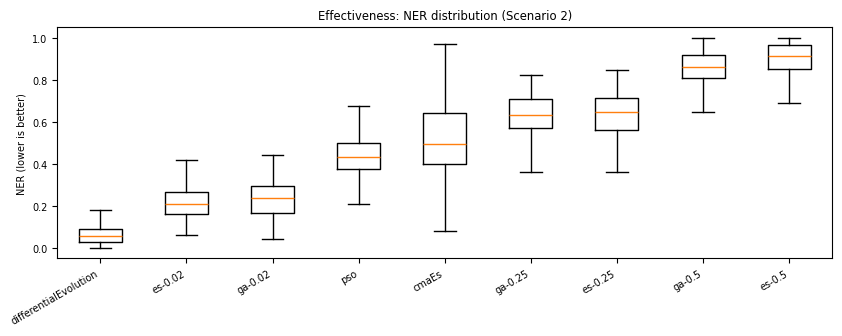

In [22]:
# Plot NER distribution per solver_sigma
plt.figure(figsize=(10, 3))
order = (ner_df.groupby('solver_sigma')['NER'].median().sort_values().index.tolist())
data = [ner_df[ner_df['solver_sigma'] == ss]['NER'].to_numpy() for ss in order]
plt.boxplot(data, labels=order, showfliers=False)
plt.xticks(rotation=30, ha='right')
plt.ylabel('NER (lower is better)')
plt.title('Effectiveness: NER distribution (Scenario 2)')
out_path = f'Figures/{experiment_name}/{experiment_name}_NER.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
print('Saved →', out_path)
plt.show()

## 3) Efficiency: EtTQ
EtTQ = số evals để đạt ngưỡng $Q_3$ của phân phối final best fitness (gộp tất cả EA×runs trên cùng problem).

In [23]:
def ettq_for_run(df_run: pd.DataFrame, threshold: float, n_eval_max: int = 10_000) -> int:
    d = df_run.sort_values('evals')
    ok = d[d['best_fitness'] <= threshold]
    if ok.empty:
        return int(n_eval_max)
    return int(ok.iloc[0]['evals'])

ettq_rows = []
for problem in problems:
    dp_final = final_df[final_df['problem'] == problem]
    thr = float(dp_final['final_best_fitness'].quantile(efficiency_percentile_reference))

    dp = united_CSV[united_CSV['problem'] == problem]
    for ss in solvers_sigmas:
        dpss = dp[dp['solver_sigma'] == ss]
        for seed in seeds:
            drun = dpss[dpss['seed'] == seed]
            if drun.empty:
                continue
            ettq_rows.append({
                'problem': problem,
                'solver_sigma': ss,
                'seed': seed,
                'EtTQ': ettq_for_run(drun, thr, n_eval_max=int(united_CSV['evals'].max()))
            })

ettq_df = pd.DataFrame(ettq_rows)
ettq_df.head(3)

,problem,solver_sigma,seed,EtTQ
0,ea.p.r.Concrete-1,cmaEs,1,1360
1,ea.p.r.Concrete-1,cmaEs,2,1785
2,ea.p.r.Concrete-1,cmaEs,3,935


Saved → Figures/Scenario_2/Scenario_2_Efficiency_percentile-0.75.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_16988\4256463442.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


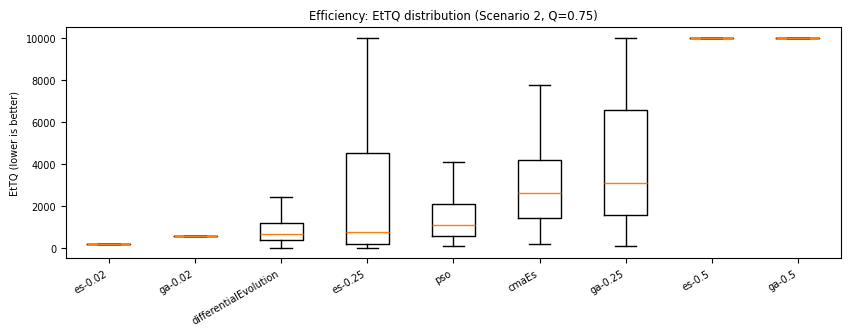

In [24]:
plt.figure(figsize=(10, 3))
order = (ettq_df.groupby('solver_sigma')['EtTQ'].median().sort_values().index.tolist())
data = [ettq_df[ettq_df['solver_sigma'] == ss]['EtTQ'].to_numpy() for ss in order]
plt.boxplot(data, labels=order, showfliers=False)
plt.xticks(rotation=30, ha='right')
plt.ylabel('EtTQ (lower is better)')
plt.title(f'Efficiency: EtTQ distribution (Scenario 2, Q={efficiency_percentile_reference})')
out_path = f'Figures/{experiment_name}/{experiment_name}_Efficiency_percentile-{efficiency_percentile_reference}.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
print('Saved →', out_path)
plt.show()

## 4) NER vs genotype size (p)
Runner đã lưu `genotype_size` (= số tham số ANN) để plot tương tự paper.

Saved → Figures/Scenario_2/Scenario_2_meanNER-vs-p.png


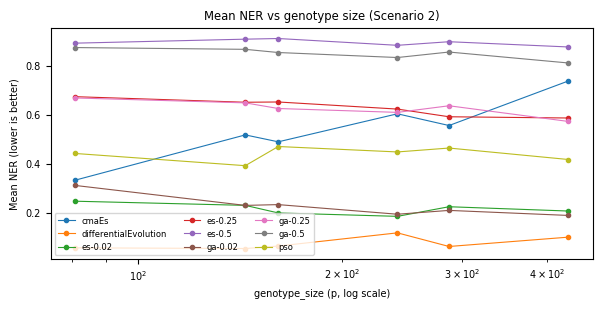

In [25]:
p_map = (united_CSV[['problem', 'genotype_size']].drop_duplicates().set_index('problem')['genotype_size'])
ner_df['genotype_size'] = ner_df['problem'].map(p_map)
mean_ner = (ner_df.groupby(['solver_sigma', 'genotype_size'])['NER'].mean().reset_index())

plt.figure(figsize=(7, 3))
for i, ss in enumerate(sorted(ner_df['solver_sigma'].unique())):
    d = mean_ner[mean_ner['solver_sigma'] == ss].sort_values('genotype_size')
    plt.plot(d['genotype_size'], d['NER'], marker='o', markersize=3, label=ss)
plt.xscale('log')
plt.xlabel('genotype_size (p, log scale)')
plt.ylabel('Mean NER (lower is better)')
plt.title('Mean NER vs genotype size (Scenario 2)')
plt.legend(ncol=3, fontsize=6)
out_path = f'Figures/{experiment_name}/{experiment_name}_meanNER-vs-p.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
print('Saved →', out_path)
plt.show()

## 5) Xuất bảng (XLSX + LaTeX)
Lưu NoVS và các thống kê cơ bản.

In [26]:
out_xlsx = f'XLSX Files/{experiment_name}/{experiment_name}_NOVS.xlsx'
novs_summary.to_frame('NoVS').to_excel(out_xlsx)
print('Saved →', out_xlsx)

out_tex = f'LaTeX/{experiment_name}/AAA_{experiment_name}_NoVS.txt'
with open(out_tex, 'w', encoding='utf-8') as f:
    f.write(novs_summary.to_frame('NoVS').to_latex())
print('Saved →', out_tex)

Saved → XLSX Files/Scenario_2/Scenario_2_NOVS.xlsx
Saved → LaTeX/Scenario_2/AAA_Scenario_2_NoVS.txt
